# CNN Fundamental Components:  Demonstration

## From an image matrix to a final prediction

This notebook demonstrates the basic components of a Convolutional Neural Network using **simple Python lists and loops**.

### Learning sequence

1. Represent an image as a matrix
2. Add zero padding
3. Apply one convolution manually
4. Apply convolution over the complete image
5. Understand stride and output size
6. Apply ReLU activation
7. Apply max and average pooling
8. Build a feature-extraction block
9. Flatten the final feature map
10. Apply a dense layer
11. Convert scores into probabilities using softmax
12. Make a final prediction
13. Apply the same operations to a real uploaded image

> The purpose is to understand the **forward pass** clearly.  
> Training, backpropagation, and automatic filter learning are not covered.

## 1. Import only the required libraries

The CNN calculations in this notebook use ordinary Python lists and loops.  
`matplotlib` is used only for visualization.

In [1]:
import math
import random
import matplotlib.pyplot as plt

random.seed(42)

## 2. Helper functions for displaying matrices

These functions make the classroom output easier to read.

In [2]:
def matrix_shape(matrix):
    rows = len(matrix)
    columns = len(matrix[0])
    return rows, columns


def print_matrix(matrix, title=None, decimals=2):
    if title is not None:
        print(title)

    for row in matrix:
        formatted_row = []

        for value in row:
            if isinstance(value, float):
                formatted_row.append(round(value, decimals))
            else:
                formatted_row.append(value)

        print(formatted_row)

    rows, columns = matrix_shape(matrix)
    print("Shape:", rows, "x", columns)
    print()

# Part A: Image and Padding

## 3. Represent a grayscale image as a matrix

A grayscale image is a two-dimensional matrix.

- Small value: dark pixel
- Large value: bright pixel

The following small matrix contains a bright vertical region. It will help us observe how an edge-detection kernel works.

In [3]:
image = [
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10]
]

print_matrix(image, "Input image matrix")

Input image matrix
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
Shape: 6 x 6



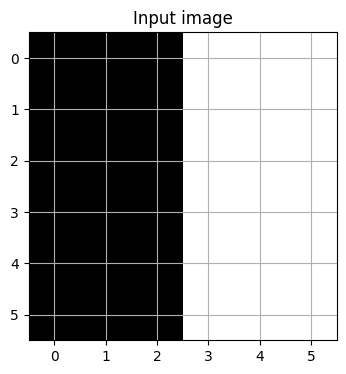

In [9]:
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Input image")
plt.axis("on")
plt.grid(True)
plt.show()


## 4. Why padding is required

Without padding, a kernel cannot be centered on boundary pixels.

For padding \(p=1\), one row and one column of zeros are added around the image.

### Manual idea

```text
Original row:       [1, 2, 3]
After padding:   [0, 1, 2, 3, 0]
```

In [10]:
sample_row = [1, 2, 3]

padded_sample_row = [0] + sample_row + [0]

print("Original row:", sample_row)
print("Padded row:  ", padded_sample_row)

Original row: [1, 2, 3]
Padded row:   [0, 1, 2, 3, 0]


## 5. Zero-padding function

This version creates a **new matrix** and does not change the original image.

In [11]:
def zero_padding(matrix, padding=1):
    if padding == 0:
        return [row[:] for row in matrix]

    original_rows = len(matrix)
    original_columns = len(matrix[0])

    padded_columns = original_columns + 2 * padding

    padded_matrix = []

    # Add top rows
    for _ in range(padding):
        padded_matrix.append([0 for _ in range(padded_columns)])

    # Add zeros to the left and right of every original row
    for row in matrix:
        new_row = []

        for _ in range(padding):
            new_row.append(0)

        for value in row:
            new_row.append(value)

        for _ in range(padding):
            new_row.append(0)

        padded_matrix.append(new_row)

    # Add bottom rows
    for _ in range(padding):
        padded_matrix.append([0 for _ in range(padded_columns)])

    return padded_matrix

In [12]:
padded_image = zero_padding(image, padding=1)

print_matrix(image, "Original image remains unchanged")
print_matrix(padded_image, "Image after zero padding")

Original image remains unchanged
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
Shape: 6 x 6

Image after zero padding
[0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 10, 10, 10, 0]
[0, 0, 0, 0, 10, 10, 10, 0]
[0, 0, 0, 0, 10, 10, 10, 0]
[0, 0, 0, 0, 10, 10, 10, 0]
[0, 0, 0, 0, 10, 10, 10, 0]
[0, 0, 0, 0, 10, 10, 10, 0]
[0, 0, 0, 0, 0, 0, 0, 0]
Shape: 8 x 8



Effect of Padding on the image

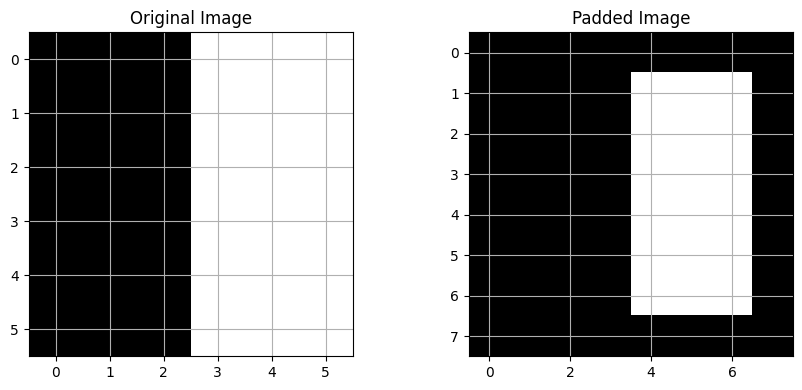

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Original image
axes[0].imshow(
    image,
    cmap="gray",
    vmin=0,
    vmax=10
)
axes[0].set_title("Original Image")
axes[0].axis("on")
axes[0].grid(True)

# Padded image
axes[1].imshow(
    padded_image,
    cmap="gray",
    vmin=0,
    vmax=10
)
axes[1].set_title("Padded Image")
axes[1].axis("on")
axes[1].grid(True)

plt.tight_layout()
plt.show()

* Effect on Real Image
* Load Image
* Apply padding
* plot


Saving cropped-removebg-preview.png to cropped-removebg-preview (3).png


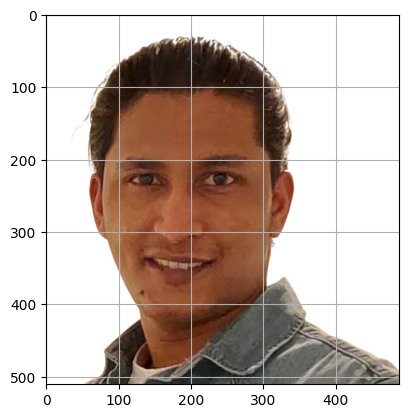

In [59]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded filename
filename = next(iter(uploaded))

# Read image
img = cv2.imread(filename)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display image
plt.imshow(img_rgb)
plt.axis("on")
plt.grid(True)
plt.show()




RGB Channel of the IMAGE

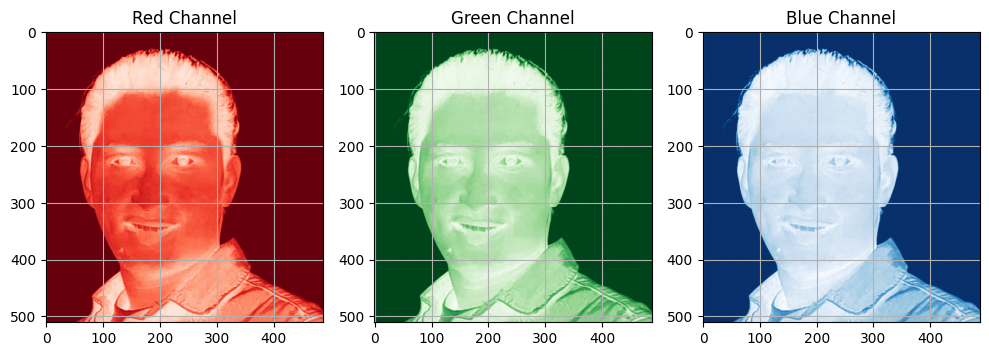

In [61]:
colors = ["Reds", "Greens", "Blues"]
titles = ["Red Channel", "Green Channel", "Blue Channel"]

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for i, (color, title) in enumerate(zip(colors, titles)):
    B = img_rgb[:, :, i]

    axes[i].imshow(B, cmap=color, vmin=0, vmax=255)
    axes[i].set_title(title)
    axes[i].axis("on")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

* Padding




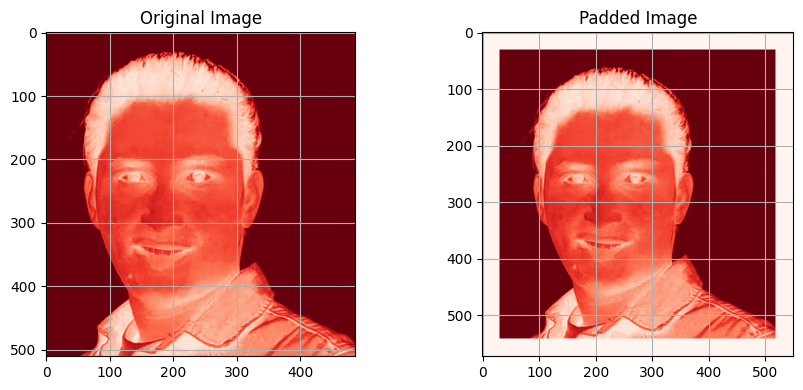

In [62]:
p = 31 # @param {"type":"slider","min":1,"max":50,"step":2}
img_rgb_r = img_rgb[:,:,0]

padded_image = zero_padding(img_rgb_r, padding=p)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Original image
axes[0].imshow(
    img_rgb_r,
    cmap="Reds",
    vmin=0,
    vmax=255
)
axes[0].set_title("Original Image")
axes[0].axis("on")
axes[0].grid(True)

# Padded image
axes[1].imshow(
    padded_image,
    cmap="Reds",
    vmin=0,
    vmax=255
)
axes[1].set_title("Padded Image")
axes[1].axis("on")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Part B: Convolution

## 6. Define a kernel

A kernel is a small matrix that detects a particular pattern.

This kernel responds strongly to a **vertical intensity change**:

\[
K=
\begin{bmatrix}
-1&0&1\\
-1&0&1\\
-1&0&1
\end{bmatrix}
\]

In [32]:
vertical_edge_kernel = [
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
]

print_matrix(vertical_edge_kernel, "Vertical-edge kernel")

Vertical-edge kernel
[-1, 0, 1]
[-1, 0, 1]
[-1, 0, 1]
Shape: 3 x 3



## 7. Perform one convolution calculation manually

At one location, convolution performs three steps:

1. Select an image patch having the same size as the kernel.
2. Multiply corresponding values.
3. Add all products.

At one position, the convolution output is calculated as

$$
\text{Output value}
=
\sum_{i=1}^{F}
\sum_{j=1}^{F}
\left(X_{ij}\times K_{ij}\right)
$$

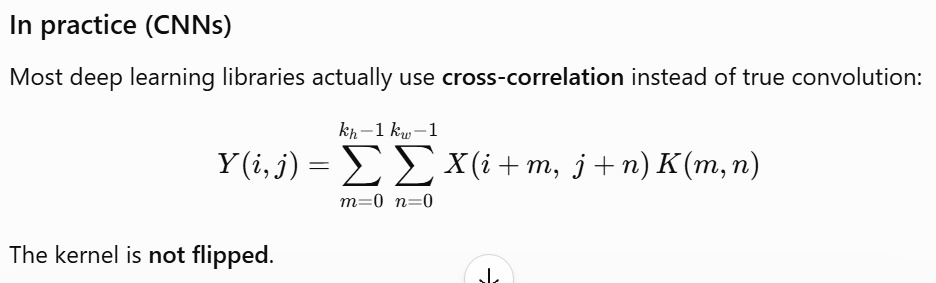

In [34]:
patch = [
    [0, 0, 10],
    [0, 0, 10],
    [0, 0, 10]
]

kernel = vertical_edge_kernel

products = []
total = 0

for row in range(3):
    product_row = []

    for column in range(3):
        product = patch[row][column] * kernel[row][column]
        product_row.append(product)
        total = total + product

    products.append(product_row)

print_matrix(patch, "Selected image patch")
print_matrix(kernel, "Kernel")
print_matrix(products, "Element-by-element products")
print("Convolution output at this position:", total)

Selected image patch
[0, 0, 10]
[0, 0, 10]
[0, 0, 10]
Shape: 3 x 3

Kernel
[-1, 0, 1]
[-1, 0, 1]
[-1, 0, 1]
Shape: 3 x 3

Element-by-element products
[0, 0, 10]
[0, 0, 10]
[0, 0, 10]
Shape: 3 x 3

Convolution output at this position: 30


### Interpretation

The output is large and positive because the selected patch contains a strong vertical change from dark pixels to bright pixels.

Now we repeat the same calculation at every valid position.

## 8. Output-size formula

For one image dimension:
The output size is calculated using

$$
O=
\left\lfloor
\frac{N-F+2P}{S}
\right\rfloor+1
$$

where:

- \(N\): input size
- \(F\): kernel size
- \(P\): padding
- \(S\): stride
- \(O\): output size



In [50]:
def output_size(input_size, kernel_size, padding, stride):
    size = ((input_size - kernel_size + 2 * padding) // stride) + 1
    return size


N = 6
F = 3
P = 1
S = 1

O = output_size(N, F, P, S)

print("Input size :", N)
print("Kernel size:", F)
print("Padding    :", P)
print("Stride     :", S)
print("Output size:", O)

Input size : 6
Kernel size: 3
Padding    : 1
Stride     : 1
Output size: 6


## 9. Complete convolution function

The function below follows exactly the same operation demonstrated manually.

In [63]:
def convolution(image, kernel, p, s):

  N = len(image)
  M = len(image[0])

  frow = len(kernel)
  fcol = len(kernel[0])

  #p = 2
  #s = 1
  I = (N-frow+2*p)/s + 1
  J = (M-fcol+2*p)/s + 1


  # Create a deep copy of the image to avoid in-place modification
  A_copy = [row[:] for row in image]
  X = zero_padding(A_copy,p)  # Padded matri

  import math
  I = math.floor(I)
  J = math.floor(J)

  conv = [[0 for _ in range(J)] for _ in range(I)]
  for i in range(I):
      for j in range(J):

        total = 0

        for m in range(frow):
          for n in range(fcol):
            total +=  (X[i*s+m][j*s+n])*kernel[m][n]

        conv[i][j] = total

  return conv

In [51]:
# @title
def convolution_standard(image, kernel, padding=0, stride=1):
    image_rows = len(image)
    image_columns = len(image[0])

    kernel_rows = len(kernel)
    kernel_columns = len(kernel[0])

    padded_image = zero_padding(image, padding)

    output_rows = (
        (image_rows - kernel_rows + 2 * padding) // stride
    ) + 1

    output_columns = (
        (image_columns - kernel_columns + 2 * padding) // stride
    ) + 1

    output = [
        [0 for _ in range(output_columns)]
        for _ in range(output_rows)
    ]

    for output_row in range(output_rows):
        for output_column in range(output_columns):

            total = 0

            for kernel_row in range(kernel_rows):
                for kernel_column in range(kernel_columns):

                    image_row = output_row * stride + kernel_row
                    image_column = output_column * stride + kernel_column

                    image_value = padded_image[image_row][image_column]
                    kernel_value = kernel[kernel_row][kernel_column]

                    total = total + image_value * kernel_value

            output[output_row][output_column] = total

    return output

Feature map after convolution
[0, 0, 10, -10]
[0, 0, 30, -30]
[0, 0, 30, -30]
[0, 0, 20, -20]
Shape: 4 x 4



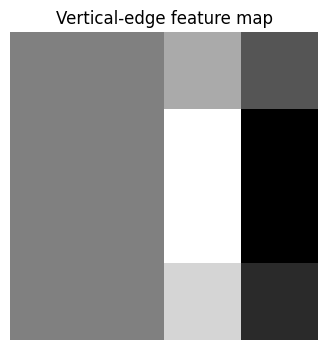

In [87]:
feature_map = convolution(
    image=image,
    kernel=vertical_edge_kernel,
    p=2,
    s=2
)

print_matrix(feature_map, "Feature map after convolution")

plt.figure(figsize=(4, 4))
plt.imshow(feature_map, cmap="gray")
plt.title("Vertical-edge feature map")
plt.axis("off")
plt.show()

In [66]:
img_rgb_r = img_rgb_r.tolist()

Convolution on Image

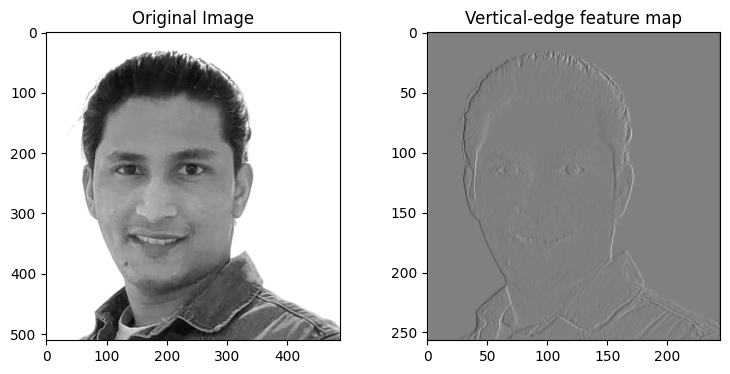

In [74]:
feature_map = convolution(
    image=img_rgb_r,
    kernel=vertical_edge_kernel,
    p=2,
    s=2
)

#print_matrix(feature_map, "Feature map after convolution")


fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Original image
axes[0].imshow(
    img_rgb_r,
    cmap="grey"
)
axes[0].set_title("Original Image")
axes[0].axis("on")
axes[0].grid(False)

# Padded image
axes[1].imshow(
    feature_map,
    cmap="grey"
)
axes[1].set_title("Vertical-edge feature map")
axes[1].axis("on")
axes[1].grid(False)

#plt.tight_layout()
plt.show()

## 10. Effect of stride

- `stride = 1`: the kernel moves one position at a time.
- `stride = 2`: the kernel moves two positions at a time.
- A larger stride produces a smaller feature map.

In [76]:
feature_map_stride_1 = convolution(
    image,
    vertical_edge_kernel,
    p=1,
    s=1
)

feature_map_stride_2 = convolution(
    image,
    vertical_edge_kernel,
    p=1,
    s=2
)

print_matrix(feature_map_stride_1, "Stride = 1")
print_matrix(feature_map_stride_2, "Stride = 2")

Stride = 1
[0, 0, 20, 20, 0, -20]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 20, 20, 0, -20]
Shape: 6 x 6

Stride = 2
[0, 20, 0]
[0, 30, 0]
[0, 30, 0]
Shape: 3 x 3



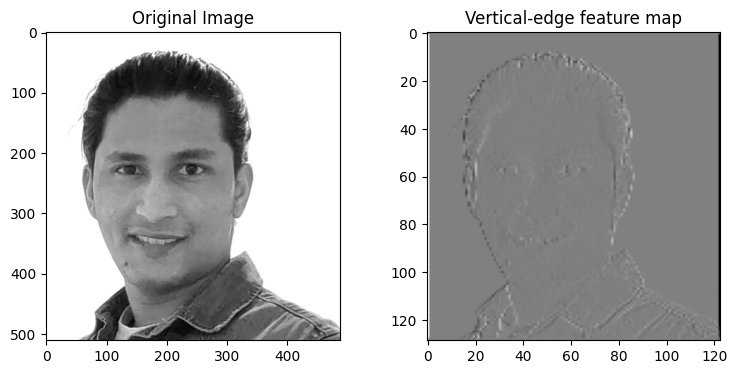

In [89]:
feature_map = convolution(
    image=img_rgb_r,
    kernel=vertical_edge_kernel,
    p=2,
    s=4
)

#print_matrix(feature_map, "Feature map after convolution")


fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Original image
axes[0].imshow(
    img_rgb_r,
    cmap="grey"
)
axes[0].set_title("Original Image")
axes[0].axis("on")
axes[0].grid(False)

# Padded image
axes[1].imshow(
    feature_map,
    cmap="grey"
)
axes[1].set_title("Vertical-edge feature map")
axes[1].axis("on")
axes[1].grid(False)

#plt.tight_layout()
plt.show()

## 11. Different kernels detect different patterns

In [79]:
# -------------------------------------------------
# Different 3 × 3 kernels
# -------------------------------------------------
kernels = {
    "Vertical Edge": [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ],

    "Horizontal Edge": [
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ],

    "Sobel Vertical": [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ],

    "Sobel Horizontal": [
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ],

    "Laplacian": [
        [ 0, -1,  0],
        [-1,  4, -1],
        [ 0, -1,  0]
    ],

    "Sharpen": [
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ],

    "Box Blur": [
        [1/9, 1/9, 1/9],
        [1/9, 1/9, 1/9],
        [1/9, 1/9, 1/9]
    ],

    "Gaussian Blur": [
        [1/16, 2/16, 1/16],
        [2/16, 4/16, 2/16],
        [1/16, 2/16, 1/16]
    ],

    "Emboss": [
        [-2, -1, 0],
        [-1,  1, 1],
        [ 0,  1, 2]
    ]
}



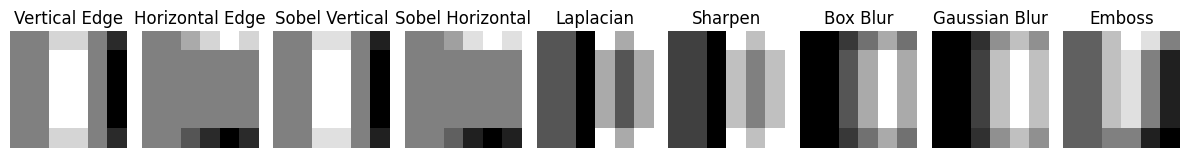

In [82]:
plt.figure(figsize=(12, 3))

plot_number = 1

for kernel_name, selected_kernel in kernels.items():

    output = convolution(
        image,
        selected_kernel,
        p=1,
        s=1
    )

    plt.subplot(1, len(kernels), plot_number)
    plt.imshow(output, cmap="gray")
    plt.title(kernel_name)
    plt.axis("off")

    plot_number = plot_number + 1

plt.tight_layout()
plt.show()

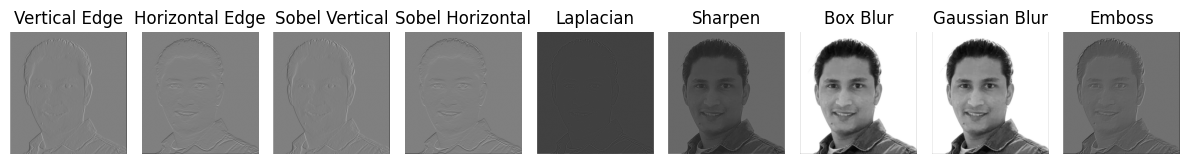

In [83]:
plt.figure(figsize=(12, 3))

plot_number = 1

for kernel_name, selected_kernel in kernels.items():

    output = convolution(
        img_rgb_r,
        selected_kernel,
        p=1,
        s=1
    )

    plt.subplot(1, len(kernels), plot_number)
    plt.imshow(output, cmap="gray")
    plt.title(kernel_name)
    plt.axis("off")

    plot_number = plot_number + 1

plt.tight_layout()
plt.show()

# Part C: Activation Function

## 12. ReLU activation

After convolution, a CNN usually applies a nonlinear activation function.

$$
\operatorname{ReLU}(x)=\max(0,x)
$$

ReLU:

- converts negative values to zero;
- keeps positive values;
- introduces nonlinearity.

In [84]:
sample_values = [-8, -2, 0, 3, 10]

relu_values = []

for value in sample_values:
    if value > 0:
        relu_values.append(value)
    else:
        relu_values.append(0)

print("Before ReLU:", sample_values)
print("After ReLU :", relu_values)

Before ReLU: [-8, -2, 0, 3, 10]
After ReLU : [0, 0, 0, 3, 10]


Activation functions

In [93]:
# -------------------------------------------------
# Activation functions
# -------------------------------------------------

def relu(x):
    return max(0, x)


def leaky_relu(x, alpha=0.01):
    if x >= 0:
        return x
    else:
        return alpha * x


def sigmoid(x):
    # Numerically stable sigmoid
    if x >= 0:
        z = math.exp(-x)
        return 1 / (1 + z)
    else:
        z = math.exp(x)
        return z / (1 + z)


def tanh(x):
    return math.tanh(x)


def elu(x, alpha=1.0):
    if x >= 0:
        return x
    else:
        return alpha * (math.exp(x) - 1)


def linear(x):
    return x




def apply_activation(feature_map, activation_function):

    activated = []

    for row in feature_map:
        activated_row = []

        for value in row:
            activated_row.append(
                activation_function(value)
            )

        activated.append(activated_row)

    return activated



In [107]:
feature_map = convolution(
    image=image,
    kernel=vertical_edge_kernel,
    p=2,
    s=2
)

activated_feature_map = apply_activation(
    feature_map,
    relu
)

print_matrix(feature_map, "Before ReLU")
print_matrix(activated_feature_map, "After ReLU")

Before ReLU
[0, 0, 10, -10]
[0, 0, 30, -30]
[0, 0, 30, -30]
[0, 0, 20, -20]
Shape: 4 x 4

After ReLU
[0, 0, 10, 0]
[0, 0, 30, 0]
[0, 0, 30, 0]
[0, 0, 20, 0]
Shape: 4 x 4



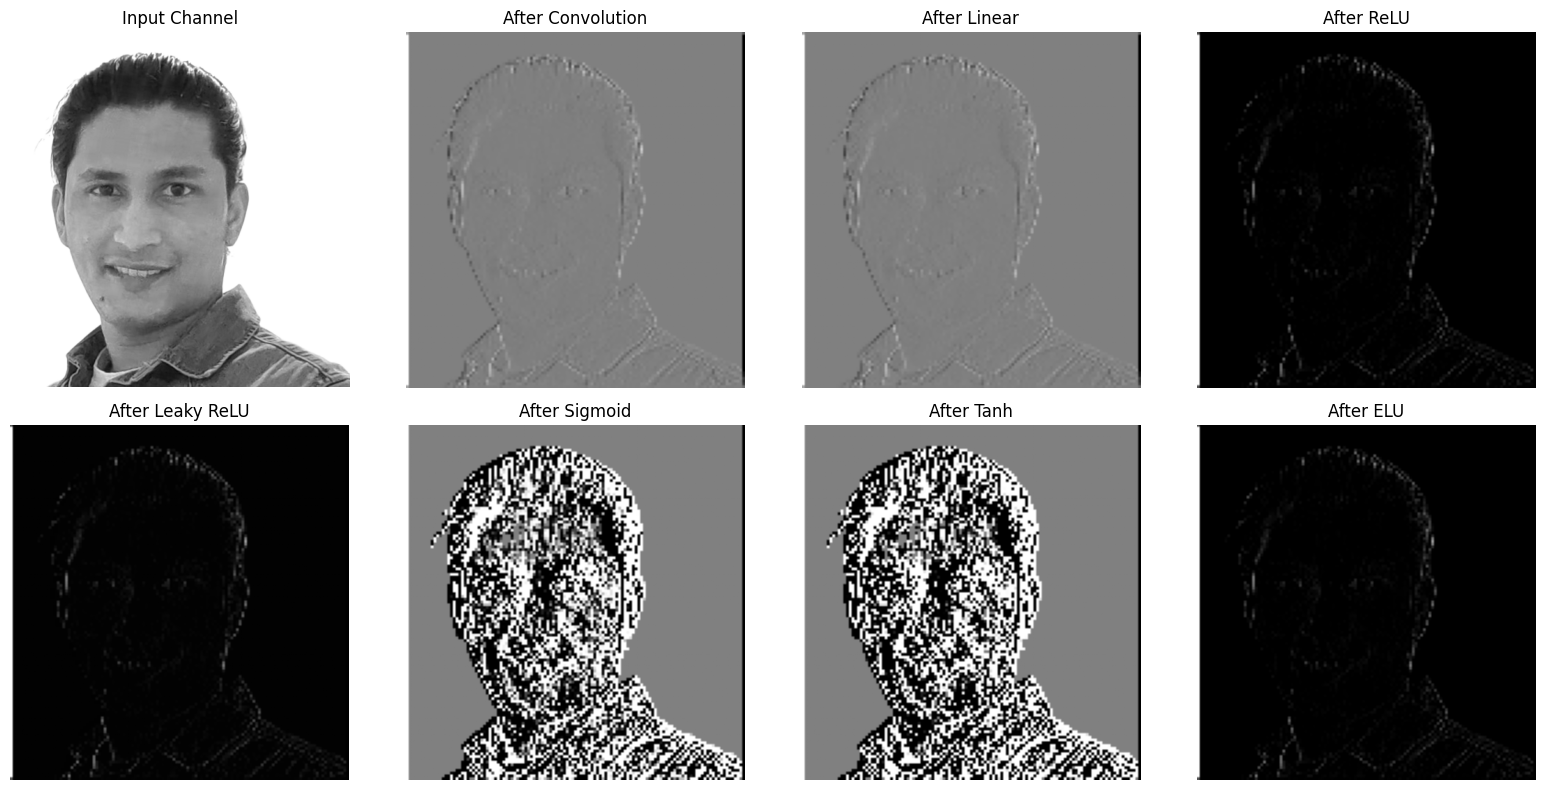

In [101]:
feature_map = convolution(
    image=img_rgb_r,
    kernel=vertical_edge_kernel,
    p=2,
    s=4
)


activation_functions = {
    "Linear": linear,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu,
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ELU": elu
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

# Input image
axes[0].imshow(img_rgb_r, cmap="grey", vmin=0, vmax=255)
axes[0].set_title("Input Channel")
axes[0].axis("off")

# Convolution output
axes[1].imshow(feature_map, cmap="gray")
axes[1].set_title("After Convolution")
axes[1].axis("off")

# Activation outputs
for i, (activation_name, activation_function) in enumerate(list(activation_functions.items())[:]):

    activated = apply_activation(
        feature_map,
        activation_function
    )

    axes[i + 2].imshow(
        activated,
        cmap="gray"
    )

    axes[i + 2].set_title(
        "After " + activation_name
    )

    axes[i + 2].axis("off")

plt.tight_layout()
plt.show()


# Part D: Pooling

## 13. Max pooling manually

Max pooling keeps the strongest response inside each local window.

$$
\begin{bmatrix}
1&3\\
2&8
\end{bmatrix}
\rightarrow 8
$$

In [102]:
pooling_window = [
    [1, 3],
    [2, 8]
]

values = []

for row in pooling_window:
    for value in row:
        values.append(value)

maximum_value = max(values)

print_matrix(pooling_window, "Pooling window")
print("Values in window:", values)
print("Max-pooled value:", maximum_value)

Pooling window
[1, 3]
[2, 8]
Shape: 2 x 2

Values in window: [1, 3, 2, 8]
Max-pooled value: 8


## 14. Max-pooling and average-pooling functions

In [ ]:
# @title
def max_pooling(feature_map, pool_size=2, stride=2):
    rows = len(feature_map)
    columns = len(feature_map[0])

    output_rows = ((rows - pool_size) // stride) + 1
    output_columns = ((columns - pool_size) // stride) + 1

    pooled_map = [
        [0 for _ in range(output_columns)]
        for _ in range(output_rows)
    ]

    for output_row in range(output_rows):
        for output_column in range(output_columns):

            values = []

            for pool_row in range(pool_size):
                for pool_column in range(pool_size):

                    row_index = output_row * stride + pool_row
                    column_index = output_column * stride + pool_column

                    values.append(
                        feature_map[row_index][column_index]
                    )

            pooled_map[output_row][output_column] = max(values)

    return pooled_map


def average_pooling(feature_map, pool_size=2, stride=2):
    rows = len(feature_map)
    columns = len(feature_map[0])

    output_rows = ((rows - pool_size) // stride) + 1
    output_columns = ((columns - pool_size) // stride) + 1

    pooled_map = [
        [0 for _ in range(output_columns)]
        for _ in range(output_rows)
    ]

    for output_row in range(output_rows):
        for output_column in range(output_columns):

            total = 0

            for pool_row in range(pool_size):
                for pool_column in range(pool_size):

                    row_index = output_row * stride + pool_row
                    column_index = output_column * stride + pool_column

                    total = total + feature_map[row_index][column_index]

            number_of_values = pool_size * pool_size
            pooled_map[output_row][output_column] = (
                total / number_of_values
            )

    return pooled_map

In [103]:
def max_pooling(feature_map, pool_size=2, stride=2):

    N = len(feature_map)
    M = len(feature_map[0])

    I = (N - pool_size) // stride + 1
    J = (M - pool_size) // stride + 1

    pooled = [[0 for _ in range(J)] for _ in range(I)]

    for i in range(I):
        for j in range(J):

            values = []

            for m in range(pool_size):
                for n in range(pool_size):

                    value = feature_map[
                        i * stride + m
                    ][
                        j * stride + n
                    ]

                    values.append(value)

            pooled[i][j] = max(values)

    return pooled

def average_pooling(feature_map, pool_size=2, stride=2):

    N = len(feature_map)
    M = len(feature_map[0])

    I = (N - pool_size) // stride + 1
    J = (M - pool_size) // stride + 1



    pooled = [[0 for _ in range(J)] for _ in range(I)]

    for i in range(I):
        for j in range(J):

            total = 0

            for m in range(pool_size):
                for n in range(pool_size):

                    total += feature_map[
                        i * stride + m
                    ][
                        j * stride + n
                    ]

            pooled[i][j] = total / (pool_size * pool_size)

    return pooled


In [109]:
feature_map = convolution(
    image=image,
    kernel=vertical_edge_kernel,
    p=2,
    s=2
)

activated_feature_map = apply_activation(
    feature_map,
    relu
)
max_pooled = max_pooling(
    activated_feature_map,
    pool_size=2,
    stride=2
)

average_pooled = average_pooling(
    activated_feature_map,
    pool_size=2,
    stride=2
)


print_matrix(image, "Image")
print_matrix(feature_map, "Convolution output")
print_matrix(activated_feature_map, "Input to pooling")
print_matrix(max_pooled, "After max pooling")
print_matrix(average_pooled, "After average pooling")

Image
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
Shape: 6 x 6

Convolution output
[0, 0, 10, -10]
[0, 0, 30, -30]
[0, 0, 30, -30]
[0, 0, 20, -20]
Shape: 4 x 4

Input to pooling
[0, 0, 10, 0]
[0, 0, 30, 0]
[0, 0, 30, 0]
[0, 0, 20, 0]
Shape: 4 x 4

After max pooling
[0, 30]
[0, 30]
Shape: 2 x 2

After average pooling
[0.0, 10.0]
[0.0, 12.5]
Shape: 2 x 2



One Feature Map Extraction

511 488
511 488
255 244
255 244


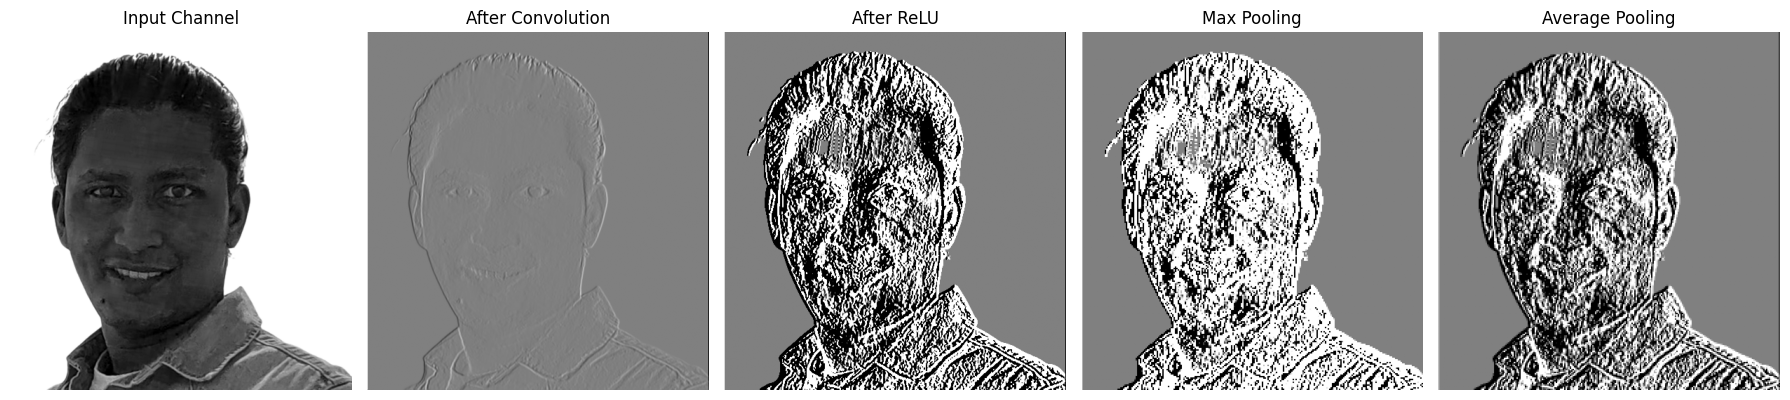

In [113]:

conv = convolution(
    img_rgb_r,
    kernels["Sobel Vertical"],
    p=1,
    s=1
)

activated = apply_activation(
    conv,
    sigmoid
)

max_pooled = max_pooling(
    activated,
    pool_size=2,
    stride=2
)

average_pooled = average_pooling(
    activated,
    pool_size=2,
    stride=2
)




print(len(conv), len(conv[0]))
print(len(activated), len(activated[0]))
print(len(max_pooled), len(max_pooled[0]))
print(len(average_pooled), len(average_pooled[0]))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(B, cmap="grey", vmin=0, vmax=255)
axes[0].set_title("Input Channel")
axes[0].axis("off")

axes[1].imshow(conv, cmap="gray")
axes[1].set_title("After Convolution")
axes[1].axis("off")

axes[2].imshow(activated, cmap="gray")
axes[2].set_title("After ReLU")
axes[2].axis("off")

axes[3].imshow(max_pooled, cmap="gray")
axes[3].set_title("Max Pooling")
axes[3].axis("off")

axes[4].imshow(average_pooled, cmap="gray")
axes[4].set_title("Average Pooling")
axes[4].axis("off")

plt.tight_layout()
plt.show()




# Part E: Complete Feature-Extraction Block

## 15. Combine convolution, ReLU, and pooling

A basic CNN feature-extraction block follows:

$$
\text{Input}
\rightarrow
\text{Convolution}
\rightarrow
\text{ReLU}
\rightarrow
\text{Pooling}
$$

In [130]:
def feature_extraction_block(
    input_map,
    kernel,
    convolution_padding=1,
    convolution_stride=2,
    pool_size=2,
    pool_stride=2
):
    convolution_output = convolution(
        image=input_map,
        kernel=kernel,
        p=convolution_padding,
        s=convolution_stride
    )

    activation_output = apply_activation(
        convolution_output,
        relu
    )

    pooling_output = max_pooling(
        activation_output,
        pool_size=pool_size,
        stride=pool_stride
    )

    return convolution_output, activation_output, pooling_output

In [115]:
convolution_output, activation_output, pooling_output = (
    feature_extraction_block(
        input_map=image,
        kernel=vertical_edge_kernel
    )
)

print_matrix(image, "1. Input")
print_matrix(convolution_output, "2. Convolution output")
print_matrix(activation_output, "3. ReLU output")
print_matrix(pooling_output, "4. Max-pooling output")

1. Input
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
[0, 0, 0, 10, 10, 10]
Shape: 6 x 6

2. Convolution output
[0, 0, 20, 20, 0, -20]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 20, 20, 0, -20]
Shape: 6 x 6

3. ReLU output
[0, 0, 20, 20, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 20, 20, 0, 0]
Shape: 6 x 6

4. Max-pooling output
[0, 30, 0]
[0, 30, 0]
[0, 30, 0]
Shape: 3 x 3



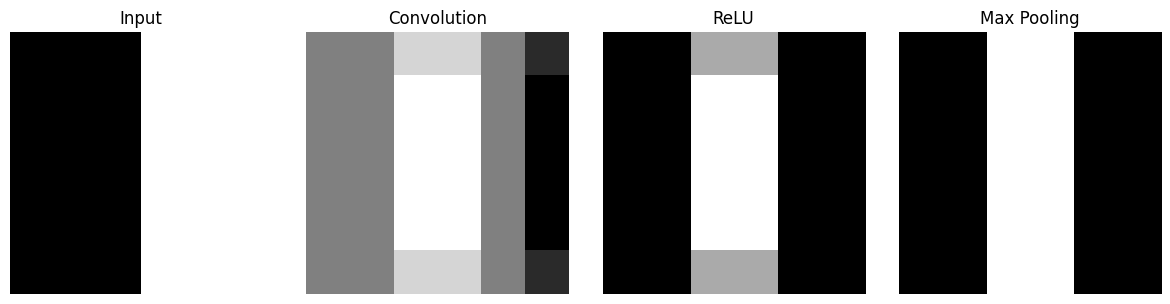

In [118]:
stages = [
    ("Input", image),
    ("Convolution", convolution_output),
    ("ReLU", activation_output),
    ("Max Pooling", pooling_output)
]

plt.figure(figsize=(12, 3))

for index in range(len(stages)):
    title = stages[index][0]
    data = stages[index][1]

    plt.subplot(1, 4, index + 1)
    plt.imshow(data, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Now on Image

511 488
511 488
255 244


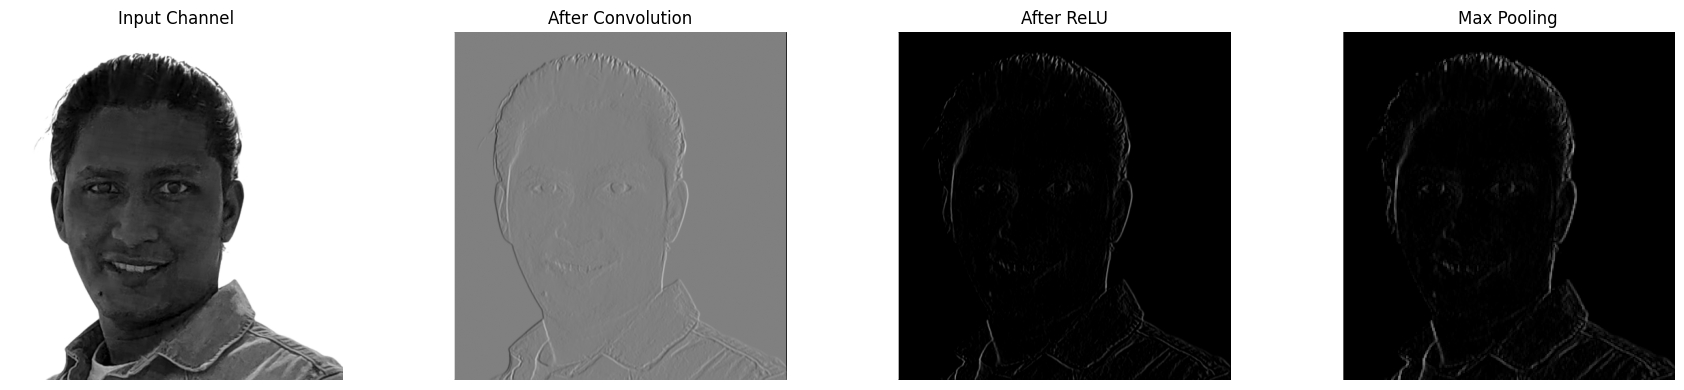

In [119]:
conv, activated, max_pooled = (
    feature_extraction_block(
        input_map=img_rgb_r,
        kernel=vertical_edge_kernel
    )
)

print(len(conv), len(conv[0]))
print(len(activated), len(activated[0]))
print(len(max_pooled), len(max_pooled[0]))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(B, cmap="grey", vmin=0, vmax=255)
axes[0].set_title("Input Channel")
axes[0].axis("off")

axes[1].imshow(conv, cmap="gray")
axes[1].set_title("After Convolution")
axes[1].axis("off")

axes[2].imshow(activated, cmap="gray")
axes[2].set_title("After ReLU")
axes[2].axis("off")

axes[3].imshow(max_pooled, cmap="gray")
axes[3].set_title("Max Pooling")
axes[3].axis("off")

plt.tight_layout()
plt.show()


## 16. Apply a second feature-extraction block

In a real CNN, several blocks are stacked.

- First block: simple edges
- Later blocks: combinations of earlier features

In [120]:
conv_1, relu_1, pool_1 = feature_extraction_block(
    input_map=image,
    kernel=kernels["Vertical Edge"],
    convolution_padding=1
)

conv_2, relu_2, pool_2 = feature_extraction_block(
    input_map=pool_1,
    kernel=kernels["Horizontal Edge"],
    convolution_padding=1
)

print_matrix(pool_1, "Output of feature-extraction block 1")
print_matrix(pool_2, "Output of feature-extraction block 2")

Output of feature-extraction block 1
[0, 30, 0]
[0, 30, 0]
[0, 30, 0]
Shape: 3 x 3

Output of feature-extraction block 2
[30]
Shape: 1 x 1



Now again on image

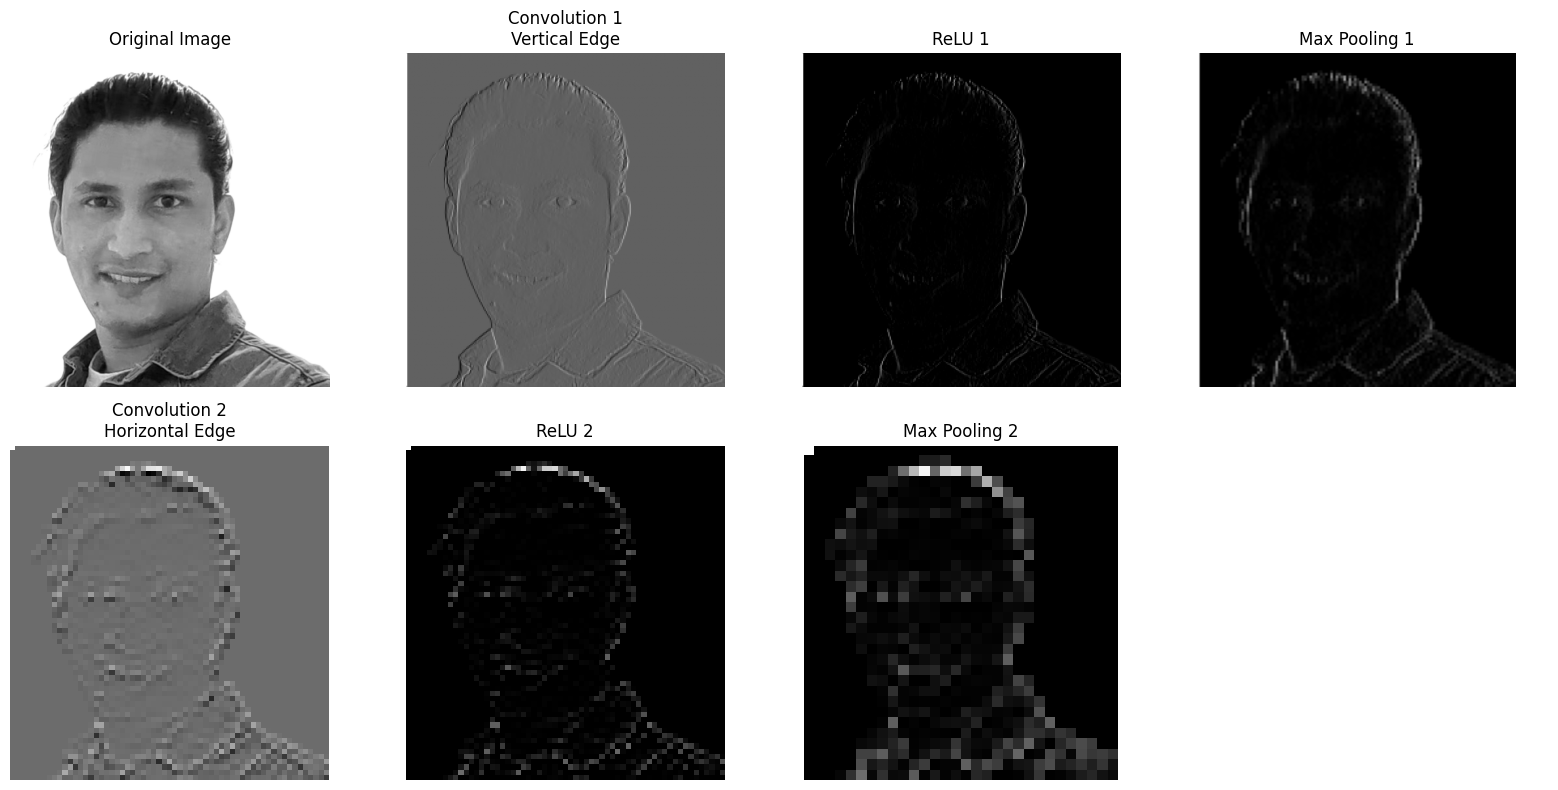

Original Image : 511 × 488
Convolution 1 Vertical Edge : 256 × 244
ReLU 1 : 256 × 244
Max Pooling 1 : 128 × 122
Convolution 2 Horizontal Edge : 64 × 61
ReLU 2 : 64 × 61
Max Pooling 2 : 32 × 30


In [131]:
conv_1, relu_1, pool_1 = feature_extraction_block(
    input_map=img_rgb_r,
    kernel=kernels["Vertical Edge"],
    convolution_padding=1
)

conv_2, relu_2, pool_2 = feature_extraction_block(
    input_map=pool_1,
    kernel=kernels["Horizontal Edge"],
    convolution_padding=1
)


# Images and corresponding titles
images_to_plot = [
    img_rgb_r,
    conv_1,
    relu_1,
    pool_1,
    conv_2,
    relu_2,
    pool_2
]

titles = [
    "Original Image",
    "Convolution 1\nVertical Edge",
    "ReLU 1",
    "Max Pooling 1",
    "Convolution 2\nHorizontal Edge",
    "ReLU 2",
    "Max Pooling 2"
]


# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Convert the 2D axes array into a simple list
axes = axes.flatten()

for i in range(len(images_to_plot)):

    # Convolution outputs can contain positive and negative values
    if i == 1 or i == 4:
        axes[i].imshow(
            images_to_plot[i],
            cmap="grey"
        )
    else:
        axes[i].imshow(
            images_to_plot[i],
            cmap="gray"
        )

    axes[i].set_title(titles[i])
    axes[i].axis("off")


# Hide the unused eighth subplot
axes[7].axis("off")

plt.tight_layout()
plt.show()



for i in range(len(images_to_plot)):

    rows = len(images_to_plot[i])
    columns = len(images_to_plot[i][0])

    print(
        titles[i].replace("\n", " "),
        ":",
        rows,
        "×",
        columns
    )

# Part F: Flatten and Classification

## 17. Flatten the final feature map

A dense layer accepts a one-dimensional vector.

$$
\begin{bmatrix}
a&b\\
c&d
\end{bmatrix}
\rightarrow
[a,b,c,d]
$$

In [132]:
def flatten(feature_map):
    flat_vector = []

    for row in feature_map:
        for value in row:
            flat_vector.append(value)

    return flat_vector


flat_features = flatten(pool_2)

print("Final feature map:")
print_matrix(pool_2)

print("Flattened vector:")
print(flat_features)

print("Flattened size:", len(flat_features))

Final feature map:
[765, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 78, 85, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 102, 328, 552, 732, 304, 615, 647, 336, 498, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 102, 102, 76, 31, 6, 0, 16, 14, 0, 1, 179, 525, 233, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 41, 24, 68, 1, 16, 10, 8, 0, 26, 0, 1, 0, 0, 432, 198, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 123, 39, 1, 30, 8, 8, 14, 10, 3, 18, 148, 90, 26, 0, 215, 249, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 196, 12, 27, 54, 85, 46, 31, 22, 81, 58, 23, 0, 14, 0, 18, 92, 132, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 27, 58, 10, 27, 45, 49, 0, 0, 10, 0, 3, 3, 20, 32, 14, 0, 0, 179, 118, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 209, 79, 50, 90, 11, 17, 8, 3, 6, 0, 5, 11, 9, 1, 6, 7, 56, 259, 109, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 47, 38, 62, 42, 48, 0, 2, 0, 7, 9, 8, 7, 0, 2, 1

## 18. Dense layer

Each output neuron calculates:

$$
z_i=\sum_j w_{ij}x_j+b_i
$$

For a simple demonstration, we generate small random weights.

In [133]:
def generate_weights(input_size, output_size):
    weights = []

    for output_neuron in range(output_size):
        neuron_weights = []

        for _ in range(input_size):
            random_weight = round(
                random.uniform(-0.1, 0.1),3)
            neuron_weights.append(random_weight)

        weights.append(neuron_weights)

    bias = [0 for _ in range(output_size)]

    return weights, bias


def dense(inputs, weights, bias):
    outputs = []

    for neuron in range(len(weights)):
        total = bias[neuron]

        for input_index in range(len(inputs)):
            total = (
                total
                + inputs[input_index] * weights[neuron][input_index]
            )

        outputs.append(total)

    return outputs

### One dense-neuron calculation

The following cell first demonstrates one neuron manually.

In [134]:
sample_inputs = [2, 3, 1]
sample_weights = [0.5, -0.2, 0.1]
sample_bias = 0.4

manual_output = sample_bias

for index in range(len(sample_inputs)):
    manual_output = (
        manual_output
        + sample_inputs[index] * sample_weights[index]
    )

print("Inputs :", sample_inputs)
print("Weights:", sample_weights)
print("Bias   :", sample_bias)
print("Neuron output:", manual_output)

Inputs : [2, 3, 1]
Weights: [0.5, -0.2, 0.1]
Bias   : 0.4
Neuron output: 0.8999999999999998


## 19. Softmax probabilities and final prediction

The dense layer produces raw scores called **logits**.  
Softmax converts them into probabilities whose sum is 1.

In [135]:
def softmax(scores):
    maximum_score = max(scores)

    exponentials = []

    for score in scores:
        exponentials.append(
            math.exp(score - maximum_score)
        )

    exponential_sum = sum(exponentials)

    probabilities = []

    for value in exponentials:
        probabilities.append(
            value / exponential_sum
        )

    return probabilities


def argmax(values):
    maximum_index = 0
    maximum_value = values[0]

    for index in range(1, len(values)):
        if values[index] > maximum_value:
            maximum_value = values[index]
            maximum_index = index

    return maximum_index

In [136]:
class_names = ["Good", "Defective"]

weights, bias = generate_weights(
    input_size=len(flat_features),
    output_size=len(class_names)
)

class_scores = dense(
    inputs=flat_features,
    weights=weights,
    bias=bias
)

probabilities = softmax(class_scores)
predicted_class_index = argmax(probabilities)
predicted_class_name = class_names[predicted_class_index]

print("Raw class scores:", class_scores)
print("Probabilities   :", probabilities)
print("Probability sum :", sum(probabilities))
print("Predicted class :", predicted_class_name)

Raw class scores: [280.02799999999974, -226.7140000000004]
Probabilities   : [1.0, 8.409025149954013e-221]
Probability sum : 1.0
Predicted class : Good


# Part G: Complete CNN Forward Pass

## 20. Put all components together

$$
\text{Image}
\rightarrow
\text{Conv}
\rightarrow
\text{ReLU}
\rightarrow
\text{Pool}
\rightarrow
\text{Flatten}
\rightarrow
\text{Dense}
\rightarrow
\text{Softmax}
\rightarrow
\text{Prediction}
$$

The weights are random in this classroom demonstration, so the prediction is not meaningful yet. During training, CNN learns the kernels and dense-layer weights from labeled examples.

In [137]:
def cnn_forward_demo(image, kernel, class_names):
    # Feature extraction
    conv_output = convolution(
        image,
        kernel,
        p=1,
        s=1
    )

    relu_output = apply_activation(
        conv_output,
        relu
    )

    pool_output = max_pooling(
        relu_output,
        pool_size=2,
        stride=2
    )

    # Classification
    flat_output = flatten(pool_output)

    weights, bias = generate_weights(
        input_size=len(flat_output),
        output_size=len(class_names)
    )

    class_scores = dense(
        flat_output,
        weights,
        bias
    )

    class_probabilities = softmax(class_scores)
    prediction_index = argmax(class_probabilities)

    return {
        "convolution": conv_output,
        "relu": relu_output,
        "pooling": pool_output,
        "flatten": flat_output,
        "scores": class_scores,
        "probabilities": class_probabilities,
        "prediction": class_names[prediction_index]
    }

In [138]:
result = cnn_forward_demo(
    image=image,
    kernel=vertical_edge_kernel,
    class_names=["Good", "Defective"]
)

print_matrix(result["convolution"], "Convolution output")
print_matrix(result["relu"], "ReLU output")
print_matrix(result["pooling"], "Pooling output")

print("Flattened features:", result["flatten"])
print("Class scores      :", result["scores"])
print("Probabilities     :", result["probabilities"])
print("Final prediction  :", result["prediction"])

Convolution output
[0, 0, 20, 20, 0, -20]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 30, 30, 0, -30]
[0, 0, 20, 20, 0, -20]
Shape: 6 x 6

ReLU output
[0, 0, 20, 20, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 30, 30, 0, 0]
[0, 0, 20, 20, 0, 0]
Shape: 6 x 6

Pooling output
[0, 30, 0]
[0, 30, 0]
[0, 30, 0]
Shape: 3 x 3

Flattened features: [0, 30, 0, 0, 30, 0, 0, 30, 0]
Class scores      : [-1.5599999999999998, 3.15]
Probabilities     : [0.008924415208431322, 0.9910755847915688]
Final prediction  : Defective


# Part H: Optional Real-Image Demonstration

## 21. Upload an image in Google Colab

This section uses Pillow only to:

- open the uploaded image;
- resize it;
- convert it into grayscale;
- convert the pixels into a Python list.

All convolution, ReLU, and pooling operations still use our own basic Python functions.

Saving cropped-removebg-preview.png to cropped-removebg-preview (4).png


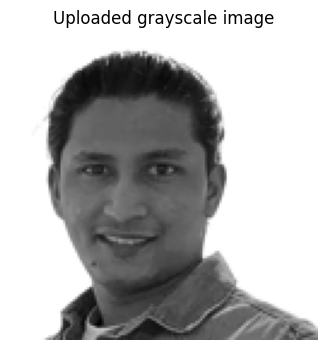

Image shape: (128, 128)


In [139]:
# Run this cell only in Google Colab.

from google.colab import files
from PIL import Image

uploaded = files.upload()

uploaded_filename = next(iter(uploaded))

real_image = Image.open(uploaded_filename)
real_image = real_image.convert("L")
real_image = real_image.resize((128, 128))

real_image_matrix = []

for row in range(real_image.height):
    matrix_row = []

    for column in range(real_image.width):
        pixel_value = real_image.getpixel((column, row))
        matrix_row.append(pixel_value)

    real_image_matrix.append(matrix_row)

plt.figure(figsize=(4, 4))
plt.imshow(real_image_matrix, cmap="gray")
plt.title("Uploaded grayscale image")
plt.axis("off")
plt.show()

print("Image shape:", matrix_shape(real_image_matrix))

## 22. Apply a vertical-edge kernel to the uploaded image

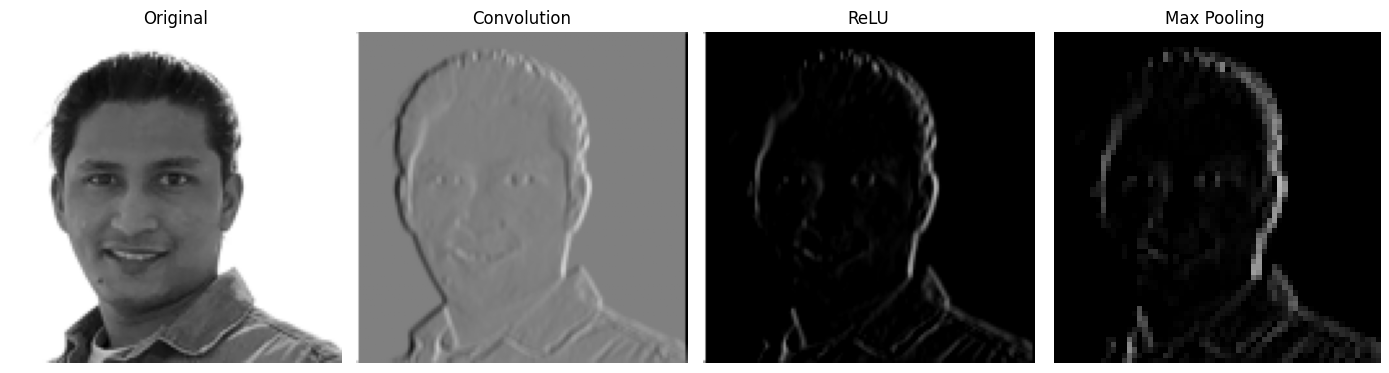

Original shape   : (128, 128)
Convolution shape: (128, 128)
ReLU shape       : (128, 128)
Pooling shape    : (64, 64)


In [140]:
real_convolution = convolution(
    image=real_image_matrix,
    kernel=vertical_edge_kernel,
    p=1,
    s=1
)

real_relu = apply_activation(
    real_convolution,
    relu
)

real_pooling = max_pooling(
    real_relu,
    pool_size=2,
    stride=2
)

real_stages = [
    ("Original", real_image_matrix),
    ("Convolution", real_convolution),
    ("ReLU", real_relu),
    ("Max Pooling", real_pooling)
]

plt.figure(figsize=(14, 4))

for index in range(len(real_stages)):
    title = real_stages[index][0]
    data = real_stages[index][1]

    plt.subplot(1, 4, index + 1)
    plt.imshow(data, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Original shape   :", matrix_shape(real_image_matrix))
print("Convolution shape:", matrix_shape(real_convolution))
print("ReLU shape       :", matrix_shape(real_relu))
print("Pooling shape    :", matrix_shape(real_pooling))

# Final Summary

## What each component does

| Component | Main purpose |
|---|---|
| Image matrix | Represents pixel values |
| Padding | Preserves boundary information and controls output size |
| Kernel | Searches for a visual pattern |
| Convolution | Produces a feature map |
| Stride | Controls kernel movement and output size |
| ReLU | Removes negative responses and introduces nonlinearity |
| Pooling | Reduces spatial size while retaining important responses |
| Flatten | Converts a feature map into a vector |
| Dense layer | Combines extracted features for classification |
| Softmax | Converts class scores into probabilities |
| Argmax | Selects the most probable class |

## Main message

A CNN does not immediately see a complete object.

$$
\text{Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Features}
\rightarrow
\text{Class scores}
\rightarrow
\text{Prediction}
$$

In this notebook, the kernels and dense weights were manually selected or randomly generated.  
In a trained CNN, these parameters are learned automatically using labeled data and backpropagation.

# Questions

1. What happens to the output size when stride is increased?
2. Why does padding help preserve boundary information?
3. Why are negative convolution responses removed by ReLU?
4. What information is retained by max pooling?
5. Why must the pooled feature map be flattened before a dense layer?
6. Why is the final random prediction not yet reliable?
7. Which parameters would be learned during CNN training?